## Modelos de Ensamble y Redes Neuronales (MLP) — Detección de Fraude

En este paso no se vuelve a preprocesar la información, se toma la partición ya preparada en
`1_Preprocesamiento_y_EDA` desde `artifacts/`. Allí se hizo el escalado
(`RobustScaler` sobre `Amount`/`Time`), el split estratificado 60/20/20 y el
**balanceo con SMOTE del train**. Aquí entrenamos y comparamos los modelos.

**Propósito de los modelos:** con 0.17 % de positivos, predecir "todo legítimo" da ~99.83 % de
accuracy y 0 % de recall. Por eso medimos con **PR-AUC** y ajustamos el umbral.


## 0. Reproducibilidad e imports

In [4]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    confusion_matrix, classification_report,
)
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
import xgboost as xgb

SEED = 42
def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)   # CPU es suficiente: la red es pequeña


Dispositivo: cpu


## 1. Carga de datos preprocesados (desde `artifacts/`)

Leemos lo que generó el notebook 1. **No** re-escalamos, **no** re-particionamos y
**no** volvemos a aplicar SMOTE: ya viene hecho.
- `X_train.csv` → train **escalado y balanceado con SMOTE** (~50/50).
- `X_val.csv`, `X_test.csv` → val/test **escalados**, con la distribución real (sin SMOTE).


In [6]:
ART = "artifacts"

X_train = pd.read_csv(os.path.join(ART, "X_train.csv"))
X_val   = pd.read_csv(os.path.join(ART, "X_val.csv"))
X_test  = pd.read_csv(os.path.join(ART, "X_test.csv"))
y_train = pd.read_csv(os.path.join(ART, "y_train.csv"))["Class"].values
y_val   = pd.read_csv(os.path.join(ART, "y_val.csv"))["Class"].values
y_test  = pd.read_csv(os.path.join(ART, "y_test.csv"))["Class"].values

print("Train:", X_train.shape, "| balance:", np.bincount(y_train))
print("Val:  ", X_val.shape,  "| fraude:", f"{y_val.mean():.4%}")
print("Test: ", X_test.shape, "| fraude:", f"{y_test.mean():.4%}")
INPUT_DIM = X_train.shape[1]   # nº de variables = tamaño de la capa de entrada


Train: (341176, 31) | balance: [170588 170588]
Val:   (56962, 31) | fraude: 0.1738%
Test:  (56962, 31) | fraude: 0.1720%


## 2. Preparación para el MLP (DataLoaders)

Convertimos los DataFrames a tensores y los servimos por lotes.
**No usamos `pos_weight`:** el train ya está balanceado por SMOTE, así que ponderar
además la pérdida sería corregir dos veces el desbalance.


In [11]:
HIDDEN_DIMS = [32, 16]   # 2 capas ocultas (la rúbrica pide 1-3)
DROPOUT     = 0.3
LR          = 1e-3
WEIGHT_DECAY= 1e-4       # regularización L2 (idea de Ridge)
BATCH_SIZE  = 2048
MAX_EPOCHS  = 40
PATIENCE    = 8          # early stopping sobre PR-AUC de validación

def make_loader(Xdf, yarr, shuffle):
    Xt = torch.tensor(Xdf.values, dtype=torch.float32)
    yt = torch.tensor(np.asarray(yarr), dtype=torch.float32).unsqueeze(1)  # (N,1) para casar con la salida
    ds = TensorDataset(Xt, yt)
    g = torch.Generator().manual_seed(SEED)   # barajado reproducible
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, generator=g)

train_loader = make_loader(X_train, y_train, shuffle=True)   # barajar SOLO en entrenamiento
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)


## 3. Arquitectura del MLP

Red **pequeña a propósito**: bloques `Linear → BatchNorm → ReLU → Dropout`.
- **BatchNorm** estabiliza el entrenamiento con entradas heterogéneas.
- **ReLU** aporta la no linealidad (sin ella, apilar capas = un modelo lineal).
- **Dropout (0.3)** regulariza.
- Salida = **1 logit**; la sigmoide vive dentro de `BCEWithLogitsLoss` por estabilidad numérica.


In [12]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout):
        super().__init__()
        layers, prev = [], input_dim  # 'layers' acumula las capas; 'prev' = tamaño de entrada actual
        # Por cada tamaño de capa oculta (aquí [32, 16]) añadimos un bloque de 4 piezas:
        # 'Linear' capa densa: combina las 'prev' entradas en 'h' salidas (aquí se aprende)
        # 'BatchNorm' normaliza esas h salidas -> entrenamiento más estable y rápido
        # 'ReLu' activación no lineal: deja pasar positivos, anula negativos
        # apaga al azar el 30% de neuronas al entrenar (regularización)
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))   # capa final: 1 logit (sin activación; la sigmoide vive en la pérdida)
        self.net = nn.Sequential(*layers)  # encadena todas las capas en orden
    def forward(self, x):   # forward define cómo fluye un dato 'x' por la red, de la entrada a la salida.
        return self.net(x)

set_seed(SEED)
model = MLP(INPUT_DIM, HIDDEN_DIMS, DROPOUT).to(DEVICE)
print(model)
print("Parámetros:", sum(p.numel() for p in model.parameters()))


MLP(
  (net): Sequential(
    (0): Linear(in_features=31, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)
Parámetros: 1665


## 4. Entrenamiento con *early stopping* sobre PR-AUC

Pérdida **BCE sin ponderar** (los datos ya están balanceados). Validamos cada época con
PR-AUC sobre el set de validación (distribución real) y guardamos los mejores pesos.
`weight_decay` de Adam aporta regularización L2.


In [13]:
# @torch.no_grad(): desactiva el rastreo de gradientes en toda esta función (solo predecimos, no entrenamos).
@torch.no_grad()
def predict_proba(model, loader):
    model.eval()  # modo evaluación: apaga Dropout y fija BatchNorm
    probs, ys = [], []  # listas para ir guardando probabilidades y etiquetas reales
    for xb, yb in loader:
        p = torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy().ravel()  # model(xb) da logits -> sigmoide los pasa a probabilidad -> a CPU, a numpy, y aplanado a 1D
        probs.append(p); ys.append(yb.numpy().ravel())
    return np.concatenate(probs), np.concatenate(ys)

def train_model(model, train_loader, val_loader, max_epochs=MAX_EPOCHS, patience=PATIENCE, verbose=True):
    criterion = nn.BCEWithLogitsLoss()        # SIN pos_weight: train ya balanceado por SMOTE
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    history = {"train_loss": [], "val_loss": [], "val_ap": []}
    best_ap, best_state, bad = -1.0, None, 0
    for epoch in range(1, max_epochs + 1):
        model.train() # modo entrenamiento: Dropout y BatchNorm activos
        running = 0.0 # acumulador de la pérdida de esta época
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad() # borramos los gradientes del paso anterior
            loss = criterion(model(xb), yb)  # la red predice y medimos el error (forward)
            loss.backward() # backpropagation: calcula cuánto "culpa" tiene cada peso del error
            optimizer.step() # optimizador ajusta los pesos para bajar el error
            running += loss.item() * xb.size(0) # sumamos la pérdida del lote (×tamaño del lote)
        train_loss = running / len(train_loader.dataset) # pérdida media de la época

        #validación
        model.eval()
        with torch.no_grad(): # sin gradientes: más rápido y ligero
            vloss = 0.0
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                vloss += criterion(model(xb), yb).item() * xb.size(0) # acumula pérdida de validación
            vloss /= len(val_loader.dataset) # pérdida media de validación
        vp, vy = predict_proba(model, val_loader) # probabilidades y etiquetas de validación
        val_ap = average_precision_score(vy, vp) # PR-AUC de validación (nuestra métrica real)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(vloss)
        history["val_ap"].append(val_ap)
        if verbose:
            print(f"Época {epoch:02d} | train {train_loss:.4f} | val {vloss:.4f} | val PR-AUC {val_ap:.4f}")
            
        # early stopping basado en el PR-AUC de validació
        if val_ap > best_ap: # ¿mejoró el PR-AUC de validación?
            best_ap, best_state, bad = val_ap, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0 # sí: guardamos ESTOS pesos
        else:
            bad += 1 # no: contamos una época sin mejora
            if bad >= patience: # si van 8 seguidas sin mejorar
                if verbose: print(f"Early stopping en época {epoch} (mejor PR-AUC val: {best_ap:.4f})")
                break
                
    if best_state is not None: model.load_state_dict(best_state) # restauramos los MEJORES pesos (no los de la última época)
    return model, history, best_ap

set_seed(SEED)
model = MLP(INPUT_DIM, HIDDEN_DIMS, DROPOUT).to(DEVICE)
model, history, best_val_ap = train_model(model, train_loader, val_loader)


Época 01 | train 0.3227 | val 0.1326 | val PR-AUC 0.6395
Época 02 | train 0.1402 | val 0.1019 | val PR-AUC 0.6941
Época 03 | train 0.1009 | val 0.0596 | val PR-AUC 0.6814
Época 04 | train 0.0745 | val 0.0378 | val PR-AUC 0.6721
Época 05 | train 0.0572 | val 0.0278 | val PR-AUC 0.6656
Época 06 | train 0.0456 | val 0.0274 | val PR-AUC 0.6606
Época 07 | train 0.0377 | val 0.0204 | val PR-AUC 0.6543
Época 08 | train 0.0323 | val 0.0196 | val PR-AUC 0.6636
Época 09 | train 0.0280 | val 0.0160 | val PR-AUC 0.6656
Época 10 | train 0.0254 | val 0.0158 | val PR-AUC 0.6579
Early stopping en época 10 (mejor PR-AUC val: 0.6941)


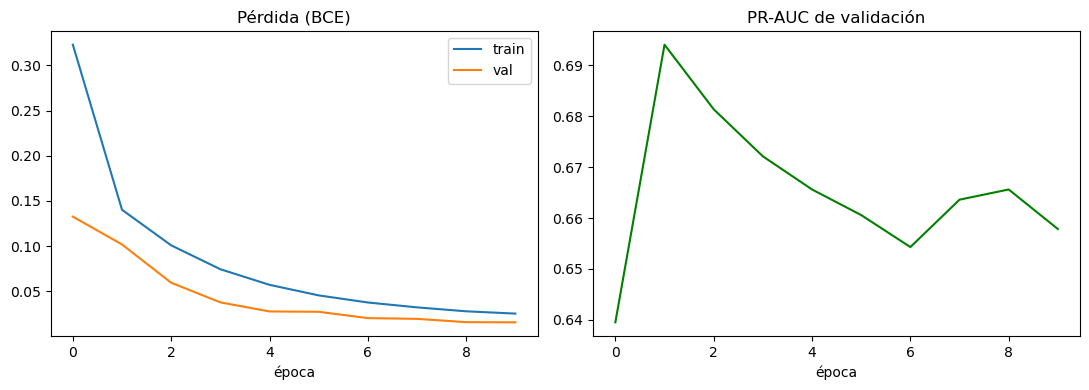

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Pérdida (BCE)"); ax[0].set_xlabel("época"); ax[0].legend()
ax[1].plot(history["val_ap"], color="green")
ax[1].set_title("PR-AUC de validación"); ax[1].set_xlabel("época")
plt.tight_layout(); plt.show()


## 5. Evaluación del MLP en TEST
PR-AUC (métrica principal) y ROC-AUC de referencia, más la curva PR.

MLP  PR-AUC = 0.7698 | ROC-AUC = 0.9744


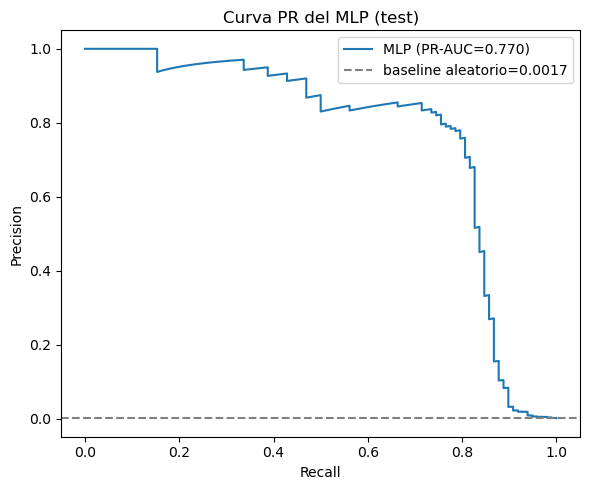

In [15]:
test_p, test_y = predict_proba(model, test_loader)
ap  = average_precision_score(test_y, test_p)
roc = roc_auc_score(test_y, test_p)
print(f"MLP  PR-AUC = {ap:.4f} | ROC-AUC = {roc:.4f}")

prec, rec, thr = precision_recall_curve(test_y, test_p)
plt.figure(figsize=(6, 5))
plt.plot(rec, prec, label=f"MLP (PR-AUC={ap:.3f})")
plt.axhline(test_y.mean(), ls="--", color="gray", label=f"baseline aleatorio={test_y.mean():.4f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Curva PR del MLP (test)")
plt.legend(); plt.tight_layout(); plt.show()


## 6. Ajuste de umbral (elegido en VALIDACIÓN)

El MLP entrega una probabilidad; como el train estaba balanceado, esa probabilidad
está descalibrada respecto a la distribución real, así que 0.5 no es el corte óptimo.
Elegimos el umbral que maximiza F1 **sobre validación** (no sobre test, para no
"hacer trampa") y lo aplicamos al test.


In [16]:
val_p, val_y = predict_proba(model, val_loader)
pv, rv, tv = precision_recall_curve(val_y, val_p)
# F1 en CADA punto de la curva: F1 = 2·P·R/(P+R). El +1e-12 evita dividir por cero.
f1v = 2 * pv * rv / (pv + rv + 1e-12)
# Índice del F1 más alto. f1s[:-1] descarta el último punto (recall=0, precision=1) que NO tiene umbral asociado (thr trae un elemento menos). nanargmax ignora posibles NaN.
best_idx = int(np.nanargmax(f1v[:-1]))
best_thr = tv[best_idx]
print(f"Umbral óptimo (max F1 en val): {best_thr:.4f}")

# Aplicamos el umbral: probabilidad >= umbral -> 1 (fraude); si no -> 0. .astype(int) lo pasa a 0/1.
y_pred = (test_p >= best_thr).astype(int)     # aplicado al test
print("\nMatriz de confusión [filas=real, cols=pred]:\n", confusion_matrix(test_y, y_pred))
# Tabla con precisión, recall, F1 y soporte (nº de casos) por clase.
print("\n", classification_report(test_y, y_pred, digits=4, target_names=["legítima", "fraude"]))


Umbral óptimo (max F1 en val): 0.9389

Matriz de confusión [filas=real, cols=pred]:
 [[56833    31]
 [   19    79]]

               precision    recall  f1-score   support

    legítima     0.9997    0.9995    0.9996     56864
      fraude     0.7182    0.8061    0.7596        98

    accuracy                         0.9991     56962
   macro avg     0.8589    0.9028    0.8796     56962
weighted avg     0.9992    0.9991    0.9991     56962



## 7. Robustez del MLP (repetición multi-semilla)

> Con el train ya balanceado por SMOTE, una validación cruzada
> *k-fold* ingenua filtraría datos sintéticos entre folds (los vecinos interpolados
> aparecen en train y en validación a la vez), inflando la métrica. Lo correcto sería
> meter SMOTE *dentro* de cada fold sobre los datos crudos. Como aquí partimos de los
> CSV ya balanceados, evaluamos la robustez reentrenando el MLP con varias semillas
> sobre la misma partición y reportando **PR-AUC media ± desviación** en test. Si las
> cifras son estables, el resultado no depende de una inicialización afortunada.


In [17]:
seeds = [42, 43, 44]
aps_seeds = []
for s in seeds:
    set_seed(s)
    m = MLP(INPUT_DIM, HIDDEN_DIMS, DROPOUT).to(DEVICE)
    m, _, _ = train_model(m, train_loader, val_loader, verbose=False)
    p, yy = predict_proba(m, test_loader)
    a = average_precision_score(yy, p); aps_seeds.append(a)
    print(f"  semilla {s}: PR-AUC = {a:.4f}")
aps_seeds = np.array(aps_seeds)
print(f"\nMLP robustez: PR-AUC = {aps_seeds.mean():.4f} ± {aps_seeds.std():.4f}")


  semilla 42: PR-AUC = 0.7672
  semilla 43: PR-AUC = 0.7567
  semilla 44: PR-AUC = 0.7877

MLP robustez: PR-AUC = 0.7705 ± 0.0129


## 8. Modelos de ensamble

Se entrenan sobre el **mismo train balanceado** y se evalúan en el **mismo test**, para
una comparación justa. **Importante:** como el train ya viene balanceado por SMOTE,
**no** añadimos ponderación extra (`scale_pos_weight`/`class_weight`); hacerlo sobre datos
ya balanceados los descompensaría.


In [19]:
# --- AdaBoost ---
set_seed(SEED)
ada = AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=SEED)
ada.fit(X_train.values, y_train)
ada_p = ada.predict_proba(X_test.values)[:, 1]
ada_ap, ada_roc = average_precision_score(test_y, ada_p), roc_auc_score(test_y, ada_p)
print(f"AdaBoost      PR-AUC={ada_ap:.4f} | ROC-AUC={ada_roc:.4f}")

# --- XGBoost ---  (learning_rate=0.1 para aprender más lento y evitar sobreajuste)
set_seed(SEED)
xgb_clf = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, random_state=SEED, eval_metric="logloss")
xgb_clf.fit(X_train.values, y_train)
xgb_p = xgb_clf.predict_proba(X_test.values)[:, 1]
xgb_ap, xgb_roc = average_precision_score(test_y, xgb_p), roc_auc_score(test_y, xgb_p)
print(f"XGBoost       PR-AUC={xgb_ap:.4f} | ROC-AUC={xgb_roc:.4f}")

# --- Random Forest ---
set_seed(SEED)
rf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
rf.fit(X_train.values, y_train)
rf_p = rf.predict_proba(X_test.values)[:, 1]
rf_ap, rf_roc = average_precision_score(test_y, rf_p), roc_auc_score(test_y, rf_p)
print(f"Random Forest PR-AUC={rf_ap:.4f} | ROC-AUC={rf_roc:.4f}")
print(f"MLP           PR-AUC={ap:.4f} | ROC-AUC={roc:.4f}")


AdaBoost      PR-AUC=0.7624 | ROC-AUC=0.9786
XGBoost       PR-AUC=0.8756 | ROC-AUC=0.9783
Random Forest PR-AUC=0.8630 | ROC-AUC=0.9713
MLP           PR-AUC=0.7698 | ROC-AUC=0.9744


## 9. Comparativa final: ensambles vs MLP

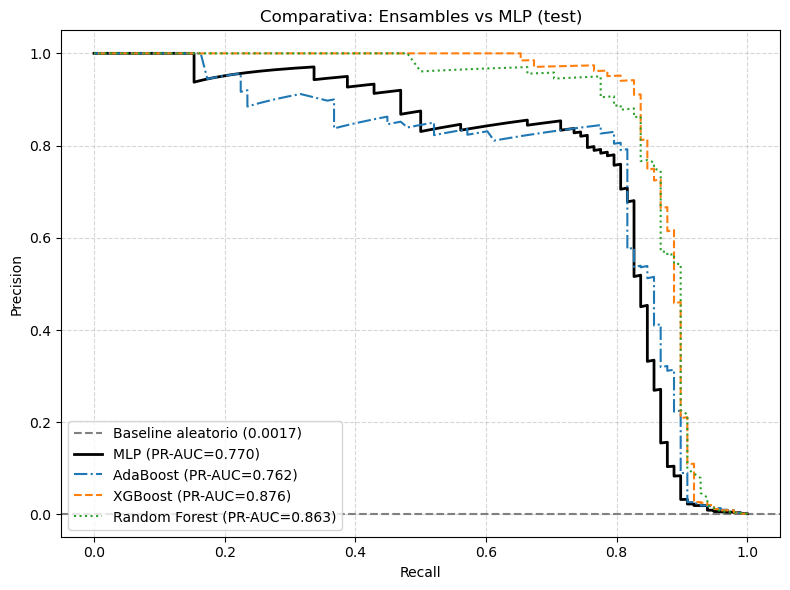

       Modelo   PR-AUC  ROC-AUC
      XGBoost 0.875607 0.978268
Random Forest 0.863038 0.971275
          MLP 0.769809 0.974386
     AdaBoost 0.762421 0.978578


In [20]:
ap_prec, ap_rec, _ = precision_recall_curve(test_y, ada_p)
xgb_prec, xgb_rec, _ = precision_recall_curve(test_y, xgb_p)
rf_prec, rf_rec, _   = precision_recall_curve(test_y, rf_p)

plt.figure(figsize=(8, 6))
plt.axhline(test_y.mean(), ls="--", color="gray", label=f"Baseline aleatorio ({test_y.mean():.4f})")
plt.plot(rec, prec, color="black", linewidth=2, label=f"MLP (PR-AUC={ap:.3f})")
plt.plot(ap_rec, ap_prec, ls="-.", label=f"AdaBoost (PR-AUC={ada_ap:.3f})")
plt.plot(xgb_rec, xgb_prec, ls="--", label=f"XGBoost (PR-AUC={xgb_ap:.3f})")
plt.plot(rf_rec, rf_prec, ls=":", label=f"Random Forest (PR-AUC={rf_ap:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Comparativa: Ensambles vs MLP (test)")
plt.legend(loc="lower left"); plt.grid(True, ls="--", alpha=0.5); plt.tight_layout(); plt.show()

resumen = pd.DataFrame({
    "Modelo": ["MLP", "AdaBoost", "XGBoost", "Random Forest"],
    "PR-AUC": [ap, ada_ap, xgb_ap, rf_ap],
    "ROC-AUC": [roc, ada_roc, xgb_roc, rf_roc],
}).sort_values("PR-AUC", ascending=False)
print(resumen.to_string(index=False))


## Explicabilidad — Importancia de variables (XGBoost)

Como XGBoost fue el mejor modelo, revisamos **qué variables** usa para detectar fraude.
Esto aporta la explicabilidad que pide la rúbrica: la importancia de variables de XGBoost,
frente a los coeficientes no nulos de Lasso del notebook 2.

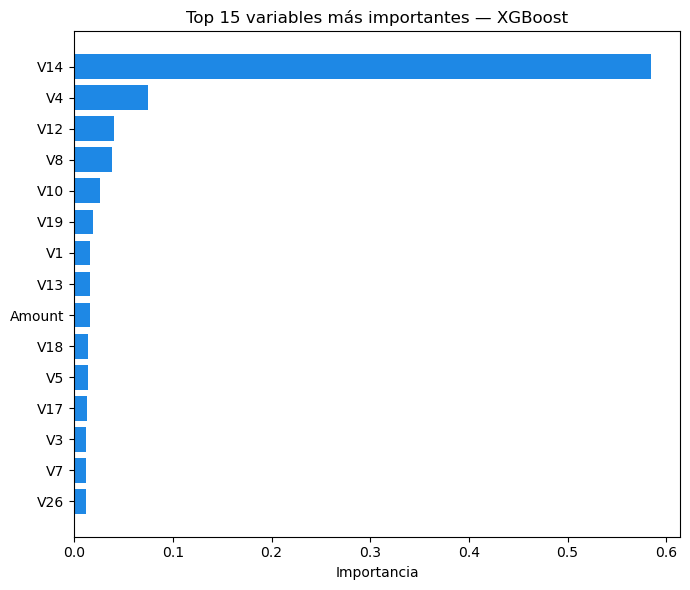

Top 10 variables para XGBoost:
variable  importancia
     V14     0.584702
      V4     0.074605
     V12     0.040363
      V8     0.037973
     V10     0.025844
     V19     0.018842
      V1     0.016138
     V13     0.016023
  Amount     0.015915
     V18     0.013924


In [22]:
# Importancia relativa que XGBoost asigna a cada variable.
# Entrenamos con X_train.values, así que mapeamos por POSICIÓN a los nombres de columna.
importancias = pd.DataFrame({
    "variable": X_train.columns,
    "importancia": xgb_clf.feature_importances_,
}).sort_values("importancia", ascending=False)

top = importancias.head(15)
plt.figure(figsize=(7, 6))
plt.barh(top["variable"][::-1], top["importancia"][::-1], color="#1E88E5")
plt.xlabel("Importancia"); plt.title("Top 15 variables más importantes — XGBoost")
plt.tight_layout(); plt.show()

print("Top 10 variables para XGBoost:")
print(importancias.head(10).to_string(index=False))

Las variables más importantes para XGBoost fueron **V14, V4, V12, V8 y V10**,
con **V14 dominando de forma notable** (~58 % de la importancia total). Esto es **coherente
con el EDA del notebook 1**: V14, V12 y V10, tres de las cuatro variables que el análisis
exploratorio señaló como las más discriminantes, están en el top 5, y V17 (la cuarta) figura
también dentro del top 15. Que el modelo ganador confirme las mismas variables refuerza que
la señal de fraude es real y no ruido. XGBoost además incorporó V4 y V8, que el EDA no había
destacado, captando señal adicional.

Es notable que las variables más importantes sean componentes PCA y **no** `Amount` (modesto,
~puesto 9) ni `Hour` (que no entra al top 15): el patrón de fraude vive en la estructura
latente de las transacciones, no en el monto ni en la hora.

A diferencia de Lasso (notebook 2), que hace selección de variables llevando coeficientes a
cero, XGBoost mide la importancia por cuánto contribuye cada variable a las divisiones de sus
árboles. Vale la pena contrastar este top con los coeficientes no nulos de Lasso para ver si
ambos métodos coinciden en las variables clave.

## 10. Interpretación de resultados

Para medir el rendimiento real, probamos los modelos con el set de test respetando la distribución original (sin SMOTE, ~0.17% de fraude). Los resultados de PR-AUC fueron: XGBoost (0.876), Random Forest (0.863), MLP (0.770) y AdaBoost (0.762). Si nos hubiéramos guiado solo por el ROC-AUC, habríamos pensado que todos eran igual de buenos porque quedaron pegados entre 0.971 y 0.979, pero el PR-AUC nos dio la verdadera perspectiva.

¿Por qué pasó esto? En problemas tan desbalanceados, el accuracy no es útil (dar un diagnóstico negativo a todo nos daría un 99.83% tramposo) y el ROC-AUC se distorsiona porque la enorme cantidad de transacciones legítimas suaviza visualmente los errores. AdaBoost es la prueba viviente de esto: tiene el ROC-AUC más alto (0.979) pero el PR-AUC más bajo (0.762). Esto significa que ordena bien las transacciones de forma general, pero es pésimo cuando intentamos ajustar el umbral para atrapar los fraudes reales sin generar una alerta masiva de falsos positivos.

El ''mejor modelo'' para esta parte fue XGBoost, seguido muy de cerca por Random Forest. Nos hace mucho sentido ya que para datos tabulares (incluso procesados con PCA), los modelos basados en árboles suelen ganarle a las redes neuronales. El algoritmo de XGBoost funcionó mejor porque va construyendo árboles que corrigen de forma dirigida los fallos de los anteriores, y al usar un learning rate bajo (0.1) junto con regularización, aprende de forma gradual sin sobreajustar o memorizar el ruido del dataset. Random Forest se defendió muy bien promediando árboles independientes (bagging), pero la optimización secuencial de XGBoost le sacó ventaja.

Por último, el MLP (0.770) no pudo alcanzar el nivel de los árboles. Aunque aplicar SMOTE le dio un empujón muy grande (subió de un ~0.70 que obtenía usando pesos en la pérdida), al haber tan pocos casos de fraude reales en un entorno tabular, la red neuronal no cuenta con la estructura necesaria para destacar, quedando por detrás de las soluciones basadas en árboles de decisión.


In [21]:
# Guardado de métricas reproducibles
import json as _json
os.makedirs("artifacts", exist_ok=True)
torch.save(model.state_dict(), "artifacts/mlp_fraud.pt")
metrics = {
    "mlp_pr_auc": float(ap), "mlp_roc_auc": float(roc),
    "adaboost_pr_auc": float(ada_ap), "adaboost_roc_auc": float(ada_roc),
    "xgboost_pr_auc": float(xgb_ap), "xgboost_roc_auc": float(xgb_roc),
    "random_forest_pr_auc": float(rf_ap), "random_forest_roc_auc": float(rf_roc),
    "best_threshold": float(best_thr), "best_val_pr_auc": float(best_val_ap),
    "mlp_robustez_mean": float(aps_seeds.mean()), "mlp_robustez_std": float(aps_seeds.std()),
    "seed": SEED,
}
with open("artifacts/mlp_metrics.json", "w") as f:
    _json.dump(metrics, f, indent=2)
print("Guardado en artifacts/:", metrics)


Guardado en artifacts/: {'mlp_pr_auc': 0.7698085408929316, 'mlp_roc_auc': 0.9743857165826375, 'adaboost_pr_auc': 0.7624206727756818, 'adaboost_roc_auc': 0.9785777809998506, 'xgboost_pr_auc': 0.8756065601670232, 'xgboost_roc_auc': 0.9782680552524893, 'random_forest_pr_auc': 0.8630380462257068, 'random_forest_roc_auc': 0.9712748211271003, 'best_threshold': 0.938944935798645, 'best_val_pr_auc': 0.6940517073926467, 'mlp_robustez_mean': 0.770507331513799, 'mlp_robustez_std': 0.012856753538406198, 'seed': 42}
